<a href="https://colab.research.google.com/github/cyberdslayer/yogaDev/blob/main/minor_project_yogdev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## *Importing required libraries*

In [ ]:
import pandas as pd
import gensim
import matplotlib.pyplot as plt

## *Merged 2 excel sheets datasets, in total we have used 329 asanas benefits*

In [ ]:
df = pd.read_csv('test.csv')

In [ ]:
df

,Asana,Benefits
0,PADOTTHANASANA,This asana strengthens\nthe abdominal muscles ...
1,PARVATASANA,This pose strengthens the nerves and muscles i...
2,ARDHA TITALI ASANA,This is an excellent \npreparatory practice fo...
3,GATYATMAK MERU \nVAKRASANA,This asana removes stiffness \nof the back and...
4,SIDEWAYS VIEWING,Sideways viewing relaxes the \ntension of the ...
...,...,...
321,kapilasana,"1. Helps in stretching legs, hamstrings, arms,..."
322,omkarasana,It relieves the pain of hands and feet( It is ...
323,kashyapawsana,1. This asana provides a deep muscular massage...
324,bhunamanasana,1. Bhunamanasana stretches and improves the fl...


In [ ]:
#shape of the data frame
df.shape

(326, 2)

## *Removing Stop words at first and converting it into lower cases so that all stop words can be remove which were in Upper cases.*


In [ ]:
import nltk # NLP Toolkit
from nltk.corpus import stopwords
#Stopwords are common words in a language that are often filtered out during NLP
nltk.download('stopwords')
stop = stopwords.words('english')
#  1st step for removing stop words is to use the library and remove stop words, this will make
# sure that some basic stop words and numerical values is been removed from the Benefits column.

# 2nd step is that there might be stop words present in upper case for example "This" is a stop words
# which was not removed in 1st step so I converted the Benefits column to lower case. Moreover we can only
# lowercase any sentence or entire column when that column is free of any numerical value.

# 3rd then further removing stopwords, in this way we get the whole benefits column free from stop words


from gensim.parsing.preprocessing import remove_stopwords
from gensim.parsing.preprocessing import strip_non_alphanum
from gensim.parsing.preprocessing import strip_numeric
from gensim.parsing.preprocessing import strip_multiple_whitespaces
df['Benefits'] = df['Benefits'].apply(str.lower)
df['Benefits']=df.Benefits.apply(remove_stopwords)
df['Benefits']=df.Benefits.apply(strip_non_alphanum)
df['Benefits']=df.Benefits.apply(strip_numeric)
df['Benefits']=df.Benefits.apply(strip_multiple_whitespaces)
df['Asana']=df.Asana.apply(strip_multiple_whitespaces)
df['Asana'] = df['Asana'].apply(str.lower)
df

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,Asana,Benefits
0,padotthanasana,asana strengthens abdominal muscles massages o...
1,parvatasana,pose strengthens nerves muscles limbs back hel...
2,ardha titali asana,excellent preparatory practice loosening knee ...
3,gatyatmak meru vakrasana,asana removes stiffness increases flexibility ...
4,sideways viewing,sideways viewing relaxes tension muscles strai...
...,...,...
321,kapilasana,helps stretching legs hamstrings arms chest b...
322,omkarasana,relieves pain hands feet helpful rheumatism gi...
323,kashyapawsana,asana provides deep muscular massage abdomen ...
324,bhunamanasana,bhunamanasana stretches improves flexibility ...


## *We have further removed special characters and tokenized each row of benefits.*

In [ ]:
# this will create the list of each benefit rows
benefits =df['Benefits'].apply(gensim.utils.simple_preprocess)
print(benefits)

0      [asana, strengthens, abdominal, muscles, massa...
1      [pose, strengthens, nerves, muscles, limbs, ba...
2      [excellent, preparatory, practice, loosening, ...
3      [asana, removes, stiffness, increases, flexibi...
4      [sideways, viewing, relaxes, tension, muscles,...
                             ...                        
321    [helps, stretching, legs, hamstrings, arms, ch...
322    [relieves, pain, hands, feet, helpful, rheumat...
323    [asana, provides, deep, muscular, massage, abd...
324    [bhunamanasana, stretches, improves, flexibili...
325    [stretches, strengthens, lengthens, mandalasan...
Name: Benefits, Length: 326, dtype: object


In [ ]:
# prints the words present in the benefit row 1
benefits[0]

['asana',
 'strengthens',
 'abdominal',
 'muscles',
 'massages',
 'organs',
 'strengthens',
 'digestive',
 'system',
 'lower',
 'back',
 'pelvic',
 'perineal',
 'muscles',
 'helps',
 'correct',
 'prolapse']

## *Implemented Word2Vec with following features:*
* window size = 5
* minimum word cound for which the model can input row wise data = 2
* required cpu  threads to train the model = 4
* size of the required vector embedding = 50

In [ ]:
model = gensim.models.Word2Vec(
    window=5,
    min_count=2,
    workers=4,
    #size = 50  <-deprecated parameter for Word2Vec
)


## *Building vocabulary of unique words present in the entire benefit column*

In [ ]:

model.build_vocab(benefits, progress_per=5)
# vocab_len = len(model.wv)
# print(vocab_len)

In [ ]:
model.train(benefits, total_examples=model.corpus_count, epochs=2000)

(22225151, 29294000)

## *We can test our model for any words suppose say sciatica we will get the similar words in benefits*

In [ ]:
#when we find the similar words for a disease in
#Benefits section we also see that we get the names of asanas also.
#like for this word we get similar words like chakrasana, marjariasana, shalabhasana which indicates
#that since we have taken these words from benefits section, it means that for this particular diseaes
#most prpbable asanas can be chakrasana, marjariasana, shalabhasana etc.  to cure it.
a = model.wv.most_similar("sciatica", topn= 100)

#print(type(model.wv.most_similar("sciatica", topn= 100)))

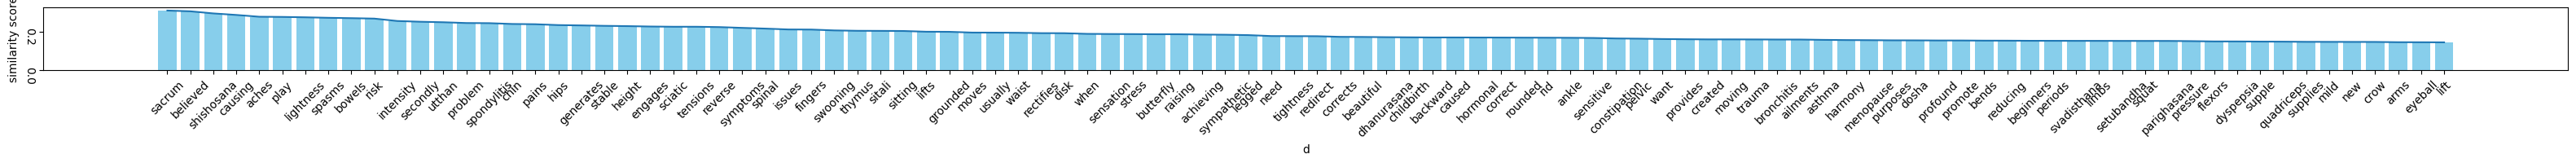

In [ ]:
df = pd.DataFrame(a);
d = df[0]
d=df[0].tolist()
e=df[1].tolist()

plt.figure(figsize=(40,1)) # Set the figure size here
plt.bar(d, e, color='skyblue')
plt.xlabel('d')
plt.ylabel('similarity score')
plt.xticks(rotation=45)
plt.yticks(rotation=270)
plt.plot(d,e)
plt.show()

## *Printing one of the benefits column word's vector*

In [ ]:
# suppose we want to know the vector embedding of a word 'pain' so we have printed the vector embedding of size 50
import numpy as np
print((model.wv.get_vector('pain')))

[ 3.35059375e-01 -4.41075277e+00  4.87106609e+00  1.70510960e+00
  3.55623269e+00  5.57386780e+00 -8.17816556e-02  7.30200768e+00
 -5.87874842e+00  2.02117157e+00 -1.85916162e+00  9.89901662e-01
  7.40254927e+00 -1.49996865e+00 -4.67961216e+00  5.55960274e+00
  3.27183914e+00 -5.43102360e+00  4.25331259e+00  1.07554585e-01
 -1.86812222e+00 -4.13140535e-01 -1.18633795e+00  2.66307926e+00
 -3.61132431e+00  2.24025035e+00  9.40972900e+00  3.89182121e-01
  3.63413072e+00  5.51467948e-03  1.61576545e+00 -9.46196938e+00
 -1.80812919e+00  4.08685827e+00  2.76570106e+00 -3.05129504e+00
 -2.13147640e+00  6.64938354e+00 -8.80768490e+00  2.32040834e+00
 -2.16549492e+00  1.47696602e+00 -1.54610908e+00 -4.57203817e+00
 -2.14077234e+00  3.52899432e+00 -9.08735171e-02  3.55815601e+00
 -1.48305714e+00  4.92016411e+00 -2.07603025e+00  5.64449167e+00
  3.40298176e+00 -4.43552160e+00 -3.05754757e+00 -5.92404079e+00
 -3.31726521e-01  4.30753756e+00  2.19404507e+00  1.80089965e-01
  3.01299334e-01  4.43273

In [ ]:
# counts total number of rows in datasets being trained
model.corpus_count

326

In [ ]:
from gensim.models import Word2Vec
# created list of unique words from the column Benefits.
words = list(w for w in model.wv.key_to_index)


In [ ]:
# printing unique words from the vocabulary list.
print(words)

['muscles', 'body', 'pose', 'helps', 'organs', 'asana', 'spine', 'improves', 'abdominal', 'hips', 'shoulders', 'strengthens', 'blood', 'practice', 'lower', 'balance', 'stretches', 'stretch', 'tones', 'chest', 'legs', 'flexibility', 'neck', 'good', 'arms', 'abdomen', 'posture', 'mind', 'nervous', 'back', 'flow', 'yoga', 'circulation', 'reproductive', 'pelvic', 'system', 'leg', 'hip', 'entire', 'stimulates', 'awareness', 'nerves', 'spinal', 'core', 'digestive', 'deep', 'improving', 'gives', 'heart', 'joints', 'pressure', 'digestion', 'chakra', 'benefits', 'increases', 'great', 'concentration', 'strength', 'upper', 'energy', 'constipation', 'sense', 'thighs', 'like', 'functioning', 'related', 'glands', 'region', 'toning', 'breathing', 'stretching', 'knees', 'especially', 'poses', 'toned', 'breath', 'ankles', 'hamstrings', 'area', 'massages', 'liver', 'internal', 'strong', 'focus', 'help', 'better', 'the', 'improve', 'pain', 'disorders', 'alignment', 'brain', 'stability', 'feet', 'flexible

In [ ]:
# here we have the length of unique words

print(len(words))

1330


## *Created an empty dictionary at first to store the unique words as key words  along with its vector embeddings.*

In [ ]:
dict_of_word_embeddings = dict({})
for i in words:
    dict_of_word_embeddings[i] = model.wv[i]

In [ ]:
# on printing the dictionary, we get the following result.
print(dict_of_word_embeddings)

{'muscles': array([-2.722859  , -0.44619882,  0.04076899,  0.8168215 , -0.6513534 ,
       -1.3630797 ,  0.3547534 , -1.3280737 , -2.4532344 ,  2.5644474 ,
        0.34951136, -1.7437681 , -0.35961232,  1.006599  , -0.5501107 ,
       -2.1574852 ,  0.60199404, -1.8383958 , -1.9119478 , -1.6459719 ,
        2.8631124 ,  0.288024  ,  0.3977752 ,  0.439668  , -0.4275882 ,
        0.8061678 ,  0.47841144,  0.06189508, -1.2832359 , -0.00637984,
        2.0192106 ,  1.4881732 ,  0.04589056,  3.1453383 , -0.779751  ,
       -1.3550076 ,  0.44935697, -2.670253  , -2.1695375 , -2.5381854 ,
        0.22676322,  0.42041898, -1.2211741 ,  1.6596485 , -0.9501571 ,
        0.68321663, -2.5836291 ,  2.3441732 , -1.1957818 ,  0.9364731 ,
       -2.0868678 ,  0.7755404 , -1.281442  ,  0.80083984,  0.12837878,
        1.8056977 , -0.79474336, -0.31512082, -2.9251077 ,  2.038485  ,
        1.7203822 , -0.148336  , -2.1736827 , -2.7912855 , -3.8585572 ,
       -0.23300353,  1.9054381 , -1.5101304 ,  1.311

## *Exporting dictionary data into separate excel sheet/ csv file*.

In [ ]:
Unique_words = dict_of_word_embeddings.keys()
word_vectors  = dict_of_word_embeddings.values()
# print(asanas, word_vectors)
d = {'Unique_words' : Unique_words , 'Word_Vectors' : word_vectors}
dataframe = pd.DataFrame(data = d)
dataframe

,Unique_words,Word_Vectors
0,muscles,"[-3.128844, -0.33462244, -0.16067648, 0.757994..."
1,body,"[0.5901605, 0.6089719, 1.8917505, 0.4258161, 0..."
2,pose,"[-2.4901972, 0.13851428, 0.13424227, -2.334194..."
3,helps,"[-3.4814823, 2.028292, 0.6474329, -1.369855, 0..."
4,organs,"[-3.6493094, 0.89023626, -0.6400161, 0.4583048..."
...,...,...
1325,butterfly,"[-0.31776312, 4.58758, 2.5915947, 4.179403, -1..."
1326,titli,"[-1.6658461, -1.8791065, 3.9918146, 2.7730336,..."
1327,tolasana,"[-0.03815035, -0.45526844, -0.3230269, 0.25534..."
1328,improvement,"[-1.8293482, -1.029656, 0.11077989, -1.8462572..."


## *We have made list of unique asanas as after merging excel sheets there were repeated asanas*

In [ ]:
asanas = list(df['Asana'])
# total asanas present ( with repetition)
print(len(asanas))
asana = []


for x in asanas:
  if x not in asana:
    asana.append(x)
# total number of unique asanas
print(len(asana))
# list of unique asanas
print(asana)

326
293
['padotthanasana', 'parvatasana', 'ardha titali asana', 'gatyatmak meru vakrasana', 'sideways viewing', 'makarasana', 'padmasana', 'vajrasana', 'ardha chandrasana', 'yogamudrasana', 'bhujangasana', 'saithalyasana', 'bhu namanasana', 'sarvangasana', 'natarajasana', 'poorna bhujangasana', 'koormasana', 'poorna shalabhasana', 'poorna dhanurasana', 'bandha hasta utthanasana ', 'shava udarakarshanasana ', 'chakki chalanasana ', 'kashtha takshanasana ', 'vayu nishkasana', 'ushtrasana', 'samakonasana ', 'matsyasana', 'kandharasana', ' setu asana ', 'paschimottanasana', 'meru akarshanasana', 'pada hastasana', 'seetkari pranayama', 'jalandhara bandha', 'tadagi mudra', 'maha vedha mudra', 'shashankasana', 'janu chakra', 'poorna titali asana', 'manibandha chakra', 'skandha chakra', 'greeva sanchalana', 'padachakrasana', 'pada sanchalanasana', 'supta pawanmuktasana', 'jhulana lurhakanasana', 'supta udarakarshanasana', 'naukasana', 'rajju karshanasana', 'nauka sanchalanasana', 'namaskarasan

## *On-hot Encodded the asanas words and created a dictionary to store the asana word with its word embedding*

In [ ]:
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(asana)
#print(integer_encoded)
integer_encoded = integer_encoded.reshape(len(integer_encoded), 1)

### One hot encoding
onehot_encoder = OneHotEncoder(sparse=False)
onehot_encoded = onehot_encoder.fit_transform(integer_encoded)

# onehot_encoded

asan_dict={}

for i in range(len(asana)):
  asan_dict[asana[i]] = onehot_encoded[i]

print(asan_dict)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


{'padotthanasana': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
      

In [ ]:
from tensorflow import keras
from tensorflow.keras.layers import Dense

In [ ]:
# printing the benefit words of one row.
print(benefits[0])

['asana', 'strengthens', 'abdominal', 'muscles', 'massages', 'organs', 'strengthens', 'digestive', 'system', 'lower', 'back', 'pelvic', 'perineal', 'muscles', 'helps', 'correct', 'prolapse']


## *Created a Tupple associating the benefits words of each row with the respective asana. In order to bring the associativity between benefits words and asana words*

In [ ]:
pair=[]

i=0
a=len(asana)
for x in benefits:
  if(i<a):
    target=asana[i]
    for y in x:
      if(y not in words):
        continue
      pair.append((y,target))
  i+=1
print(pair)




[('asana', 'padotthanasana'), ('strengthens', 'padotthanasana'), ('abdominal', 'padotthanasana'), ('muscles', 'padotthanasana'), ('massages', 'padotthanasana'), ('organs', 'padotthanasana'), ('strengthens', 'padotthanasana'), ('digestive', 'padotthanasana'), ('system', 'padotthanasana'), ('lower', 'padotthanasana'), ('back', 'padotthanasana'), ('pelvic', 'padotthanasana'), ('muscles', 'padotthanasana'), ('helps', 'padotthanasana'), ('correct', 'padotthanasana'), ('prolapse', 'padotthanasana'), ('pose', 'parvatasana'), ('strengthens', 'parvatasana'), ('nerves', 'parvatasana'), ('muscles', 'parvatasana'), ('limbs', 'parvatasana'), ('back', 'parvatasana'), ('helps', 'parvatasana'), ('increase', 'parvatasana'), ('height', 'parvatasana'), ('stretching', 'parvatasana'), ('muscles', 'parvatasana'), ('ligaments', 'parvatasana'), ('enabling', 'parvatasana'), ('growing', 'parvatasana'), ('bones', 'parvatasana'), ('grow', 'parvatasana'), ('longer', 'parvatasana'), ('circulation', 'parvatasana'), 

## *Making a 2-D array of context words(benefit words) and Target words(asana words) by numpy stack*

In [ ]:
contexts=[dict_of_word_embeddings[context] for context,target in pair]
contexts=np.vstack(contexts)
# shape of the context words matrix
contexts.shape


(12085, 100)

In [ ]:
targets=[asan_dict[target] for context,target in pair]
targets=np.vstack(targets)
# shape of the target words matrix

targets.shape

(12085, 293)

## *Implemented **Artificial Neural Network**. with the help of tensorfow's keras functional API with the following features:*

* Number of input layer = 1
* Size of input layer = 50 unit
* Number of dense layer = 1
* size of dense layer = 1000 units
* Number of output layer = 1
* size of output unit = 293
* activation function = softmax
* loss = categorical_crossentropy
* optimizer = adam
* number of epotchs = 100

In [ ]:
from tensorflow import keras
from tensorflow.keras.layers import Dense

network_input = keras.Input(shape=contexts.shape[1], name='input_layer')
                                                                                    # Create a hidden layer for the network; store under 'hidden_layer'
hidden_layer1 = Dense(units=1000, activation='sigmoid', name='hidden_layer1')(network_input)

                                                                                            # Create an output layer for the network; store under 'output_layer'
output_layer = Dense(units=targets.shape[1], activation='softmax', name='output_layer')(hidden_layer1)

                                                                          # Create a Keras Model; store under 'embedding_model'
embedding_model = keras.Model(inputs=network_input, outputs=output_layer)

                                                          # Compile the model for training; define loss function
embedding_model.compile(loss='categorical_crossentropy',optimizer = 'adam', metrics = ['accuracy'])

                                                          # Print out a summary of the model
embedding_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 100)]             0         
                                                                 
 hidden_layer1 (Dense)       (None, 1000)              101000    
                                                                 
 output_layer (Dense)        (None, 293)               293293    
                                                                 
Total params: 394293 (1.50 MB)
Trainable params: 394293 (1.50 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## *Function which inputs the user details and suggests user with the most recommended asanas*

In [ ]:
# Fit a model to the data
embedding_model.fit(x=contexts,   # inputs
                    y=targets,   # outputs
                    batch_size=1024,  # how many pairs of words processed simultaneously
                    epochs=5000,   # how many times we loop through the whole data
                    verbose=1   # do not print training status
                   )



Streaming output truncated to the last 5000 lines.
Epoch 2501/5000
12/12 [==============================] - 0s 6ms/step - loss: 2.8468 - accuracy: 0.1523
Epoch 2502/5000
12/12 [==============================] - 0s 7ms/step - loss: 2.8459 - accuracy: 0.1527
Epoch 2503/5000
12/12 [==============================] - 0s 7ms/step - loss: 2.8453 - accuracy: 0.1527
Epoch 2504/5000
12/12 [==============================] - 0s 7ms/step - loss: 2.8431 - accuracy: 0.1537
Epoch 2505/5000
12/12 [==============================] - 0s 6ms/step - loss: 2.8439 - accuracy: 0.1504
Epoch 2506/5000
12/12 [==============================] - 0s 7ms/step - loss: 2.8475 - accuracy: 0.1499
Epoch 2507/5000
12/12 [==============================] - 0s 7ms/step - loss: 2.8447 - accuracy: 0.1543
Epoch 2508/5000
12/12 [==============================] - 0s 7ms/step - loss: 2.8437 - accuracy: 0.1532
Epoch 2509/5000
12/12 [==============================] - 0s 6ms/step - loss: 2.8458 - accuracy: 0.1508
Epoch 2510/5000
12/12 

In [ ]:
from collections import Counter
from IPython.display import clear_output

def magic():
  predicted_asanas = []
  user_input_words= []
  final_predicted_asanas = []
  number_in_words = ['first','second', 'third', 'fourth']
  for i in range(4):
    user_input_words.append(input(f"Enter {number_in_words[i]} benefit word:  "))
  for i in user_input_words:
    if i in dict_of_word_embeddings:

      input_array = np.expand_dims(dict_of_word_embeddings[i], axis=0)
      prediction = embedding_model.predict(input_array)
      flatten_pred = prediction.flatten()
      result_indices = flatten_pred.argsort()[-10:][::-1]

      for result in result_indices:
        predicted_asanas.append(asana[result])


  counter_found = Counter(predicted_asanas)
  final_predicted_asanas_with_freq = counter_found.most_common(7)
  # print(final_predicted_asanas_with_freq)

  for yoga, freq in final_predicted_asanas_with_freq:
    final_predicted_asanas.append(yoga)

  print(final_predicted_asanas)
  choice=input("Clear output: Y/N ")
  if choice=='Y':
   clear_output()


magic()

Enter first benefit word:  head
Enter second benefit word:  neck
Enter third benefit word:  pain
Enter fourth benefit word:  ache
1/1 [==============================] - 0s 16ms/step
['parivritti janu sirshasana', 'pada hastasana', ' utthita hasta padangusthasana', 'muktasana', ' eka padasana', ' santolanasana', 'tiryak bhujangasana']
Clear output: Y/N y


In [ ]:
# Gettinng Final model into joblib file

import joblib
joblib.dump(model, 'model.joblib')


['model.joblib']